In [72]:
import torch
from torch import nn
from torch import optim
from torch.nn import functional as F

device = torch.accelerator.current_accelerator()
x: torch.Tensor = torch.randn(5, 4).to(device)

class NeuralNetwork(nn.Module):
    """
    Basic Neural Network
    Structure:
    1. Input Layer: R(N x 2)
    2. Hidden Layer 1: Linear Layer (2 -> 5) + ReLU Activation
    3. Output Layer: Linear Layer (5 -> 4) + Softmax Activation
    
    X -> R(N x 2)
    """
    def __init__(self):
        super().__init__()
        self.sequential = nn.Sequential(
            nn.Linear(2, 5),
            nn.ReLU(),
            nn.Linear(5, 4),
            nn.Softmax(dim=1)
        )

    def forward(self, X: torch.Tensor) -> torch.Tensor:
        return self.sequential(X)
    
model = NeuralNetwork().to(device)
input_tensor = torch.randn(10, 2).to(device)
output = model(input_tensor)
print(output)

tensor([[0.2764, 0.1991, 0.2215, 0.3030],
        [0.1673, 0.2110, 0.2759, 0.3459],
        [0.3143, 0.1521, 0.2012, 0.3324],
        [0.1903, 0.2173, 0.2506, 0.3418],
        [0.2991, 0.1792, 0.2209, 0.3008],
        [0.3419, 0.1550, 0.1892, 0.3139],
        [0.2908, 0.1858, 0.2217, 0.3017],
        [0.2261, 0.2045, 0.2175, 0.3519],
        [0.2674, 0.1893, 0.2195, 0.3238],
        [0.2878, 0.1891, 0.2217, 0.3014]], device='mps:0',
       grad_fn=<SoftmaxBackward0>)


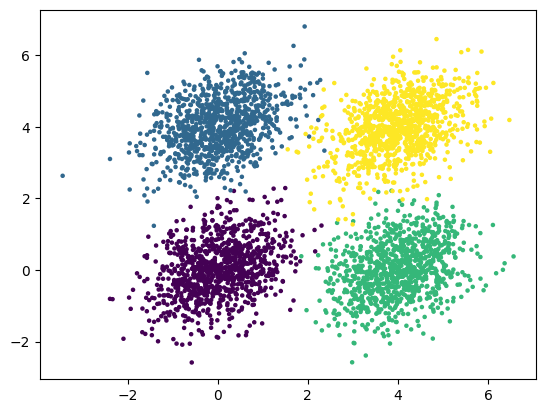

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

means = np.array([
    [0, 0],
    [0, 4],
    [4, 0],
    [4, 4],
])
cov = np.array([
    [.6, .2],
    [.2, .6]
])
N = 1000

X0 = np.random.multivariate_normal(means[0], cov, N)
X1 = np.random.multivariate_normal(means[1], cov, N)
X2 = np.random.multivariate_normal(means[2], cov, N)
X3 = np.random.multivariate_normal(means[3], cov, N)

X_np = np.vstack((X0, X1, X2, X3)).astype(np.float32)
y_np = np.array([0]*N + [1]*N + [2]*N + [3]*N)

plt.scatter(X_np[:, 0], X_np[:, 1], c=y_np, s=5, cmap="viridis")
plt.show()

In [75]:
from torch.nn import functional as F

X = torch.from_numpy(X_np).to(device)
y = torch.from_numpy(y_np).to(device)

indices = torch.randperm(X_np.shape[0])
X = X[indices]
y = y[indices]
Y = F.one_hot(y, num_classes=4).to(torch.float32)

valid_percent = 0.2
N_valid = int(valid_percent * X.shape[0])

x_valid = X[:N_valid]
y_valid = Y[:N_valid]
x_train = X[N_valid:]
y_train = Y[N_valid:]

assert x_train.shape[0] == N * 4 - N_valid
assert y_train.shape[0] == N * 4 - N_valid
assert x_valid.shape[0] == N_valid
assert y_valid.shape[0] == N_valid

In [84]:
def fit(
    X_train: torch.Tensor,
    Y_train: torch.Tensor, # one-hot encoded
    epochs: int = 1000,
    batch_size: int = 100,
    learning_rate: float = 0.01,
):
    model = NeuralNetwork().to(device)
    optimizer = optim.SGD(model.parameters(), lr=learning_rate)
    loss_function = nn.MSELoss()
    model.train()

    for epoch in range(epochs):
        for i in range(0, len(X_train), batch_size):
            batch_x = X_train[i:i + batch_size].to(device)
            pred = model(batch_x)
            
            batch_y = Y_train[i:i + batch_size].to(device)
            loss = loss_function(pred, batch_y)
            
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}")

    print(f"Final Loss: {loss.item():.4f}")

fit(x_train, y_train)

Epoch [10/1000], Loss: 0.1606
Epoch [20/1000], Loss: 0.1204
Epoch [30/1000], Loss: 0.0903
Epoch [40/1000], Loss: 0.0715
Epoch [50/1000], Loss: 0.0599
Epoch [60/1000], Loss: 0.0523
Epoch [70/1000], Loss: 0.0468
Epoch [80/1000], Loss: 0.0425
Epoch [90/1000], Loss: 0.0389
Epoch [100/1000], Loss: 0.0358
Epoch [110/1000], Loss: 0.0331
Epoch [120/1000], Loss: 0.0307
Epoch [130/1000], Loss: 0.0285
Epoch [140/1000], Loss: 0.0266
Epoch [150/1000], Loss: 0.0249
Epoch [160/1000], Loss: 0.0234
Epoch [170/1000], Loss: 0.0221
Epoch [180/1000], Loss: 0.0208
Epoch [190/1000], Loss: 0.0198
Epoch [200/1000], Loss: 0.0188
Epoch [210/1000], Loss: 0.0179
Epoch [220/1000], Loss: 0.0171
Epoch [230/1000], Loss: 0.0164
Epoch [240/1000], Loss: 0.0158
Epoch [250/1000], Loss: 0.0152
Epoch [260/1000], Loss: 0.0147
Epoch [270/1000], Loss: 0.0142
Epoch [280/1000], Loss: 0.0137
Epoch [290/1000], Loss: 0.0133
Epoch [300/1000], Loss: 0.0129
Epoch [310/1000], Loss: 0.0125
Epoch [320/1000], Loss: 0.0122
Epoch [330/1000],